# 02 — Módulo A: tipologías de municipios e índice de brecha

**Pregunta:** ¿en qué municipios de Antioquia es mayor la brecha de acceso a la
educación superior, y qué tipos de municipio existen según su perfil educativo?

**Método**
1. Matriz municipal (125 municipios) con tasas per cápita: matrícula UdeA
   regionalizada /1.000 jóvenes 15-24, beneficiarios de acompañamiento /1.000
   jóvenes 15-19, ruralidad, Saber 11 municipal y brechas de género.
2. **KMeans** sobre 7 variables estandarizadas (las variables con >50% de
   imputación se excluyen de la distancia y quedan como contexto).
   k se elige por **silhouette con k≥3** (k=2 solo reproduce la dicotomía
   urbano/rural); estabilidad verificada con ARI entre semillas.
3. **Índice de brecha (0-100)**: promedio min-max de baja matrícula, bajo
   Saber 11, alta ruralidad y baja cobertura de acompañamiento.

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent / "src"))
import pandas as pd
pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 160)

In [2]:
import module_a
module_a.main()

Módulo A: 125 municipios
  imputando mediana en BRECHA_GENERO_MATRIC: 15 municipios


Selección de k:
  k  silhouette  inercia
 2       0.350  619.912
 3       0.324  493.964
 4       0.250  421.039
 5       0.217  368.901
 6       0.225  336.364
 7       0.214  305.415
 8       0.194  291.177
k elegido por silhouette: 3


Estabilidad (ARI promedio vs 5 semillas): 0.939
  C1 (19 municipios) alta Saber 11 global y baja % rural | brecha media 61.8
  C2 (89 municipios) alta % rural y baja Saber 11 global | brecha media 72.1
  C3 (17 municipios) alta matrícula UdeA /1.000 jóv. y alta matrícula por origen /1.000 | brecha media 50.5


Top 10 municipios con mayor brecha:
NOMBRE_MUNI                                TIPOLOGIA  INDICE_BRECHA
    BETULIA C2 · alta % rural y baja Saber 11 global           86.1
    MURINDO C2 · alta % rural y baja Saber 11 global           85.2
    ITUANGO C2 · alta % rural y baja Saber 11 global           84.4
  ANGOSTURA C2 · alta % rural y baja Saber 11 global           84.3
    CAICEDO C2 · alta % rural y baja Saber 11 global           83.8
    URAMITA C2 · alta % rural y baja Saber 11 global           81.3
 MONTEBELLO C2 · alta % rural y baja Saber 11 global           81.1
       ANZA C2 · alta % rural y baja Saber 11 global           81.0
ANGELOPOLIS C2 · alta % rural y baja Saber 11 global           80.6
    NECOCLI C2 · alta % rural y baja Saber 11 global           80.3
Módulo A completo -> outputs/


## Selección de k y estabilidad

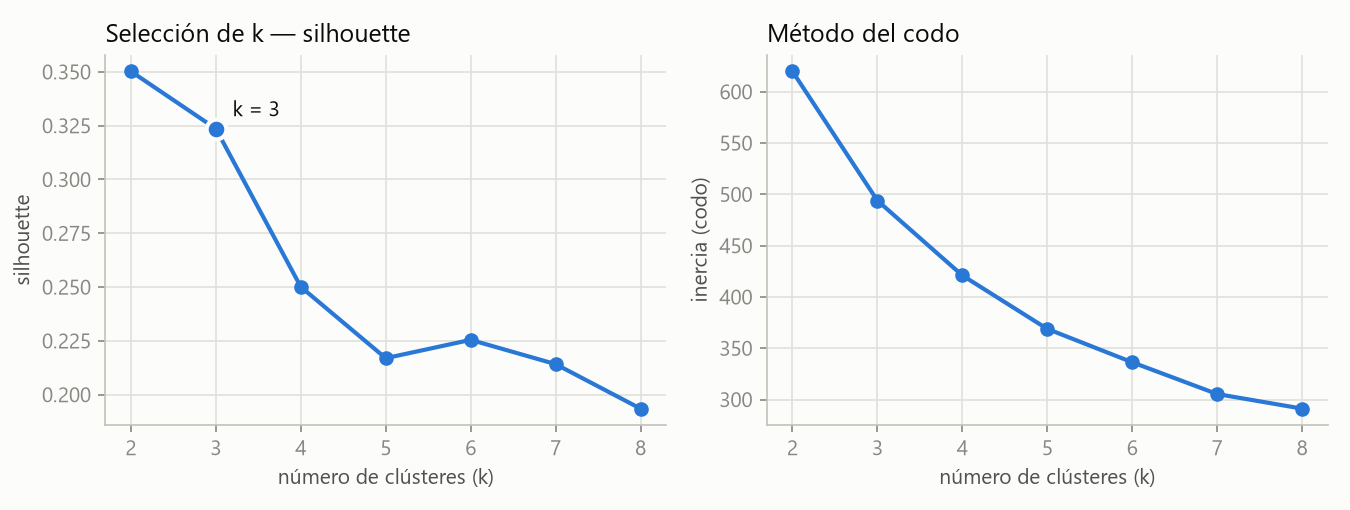

In [3]:
from IPython.display import Image
Image("../outputs/fig_k_seleccion.png")

## Tipologías resultantes (PCA)

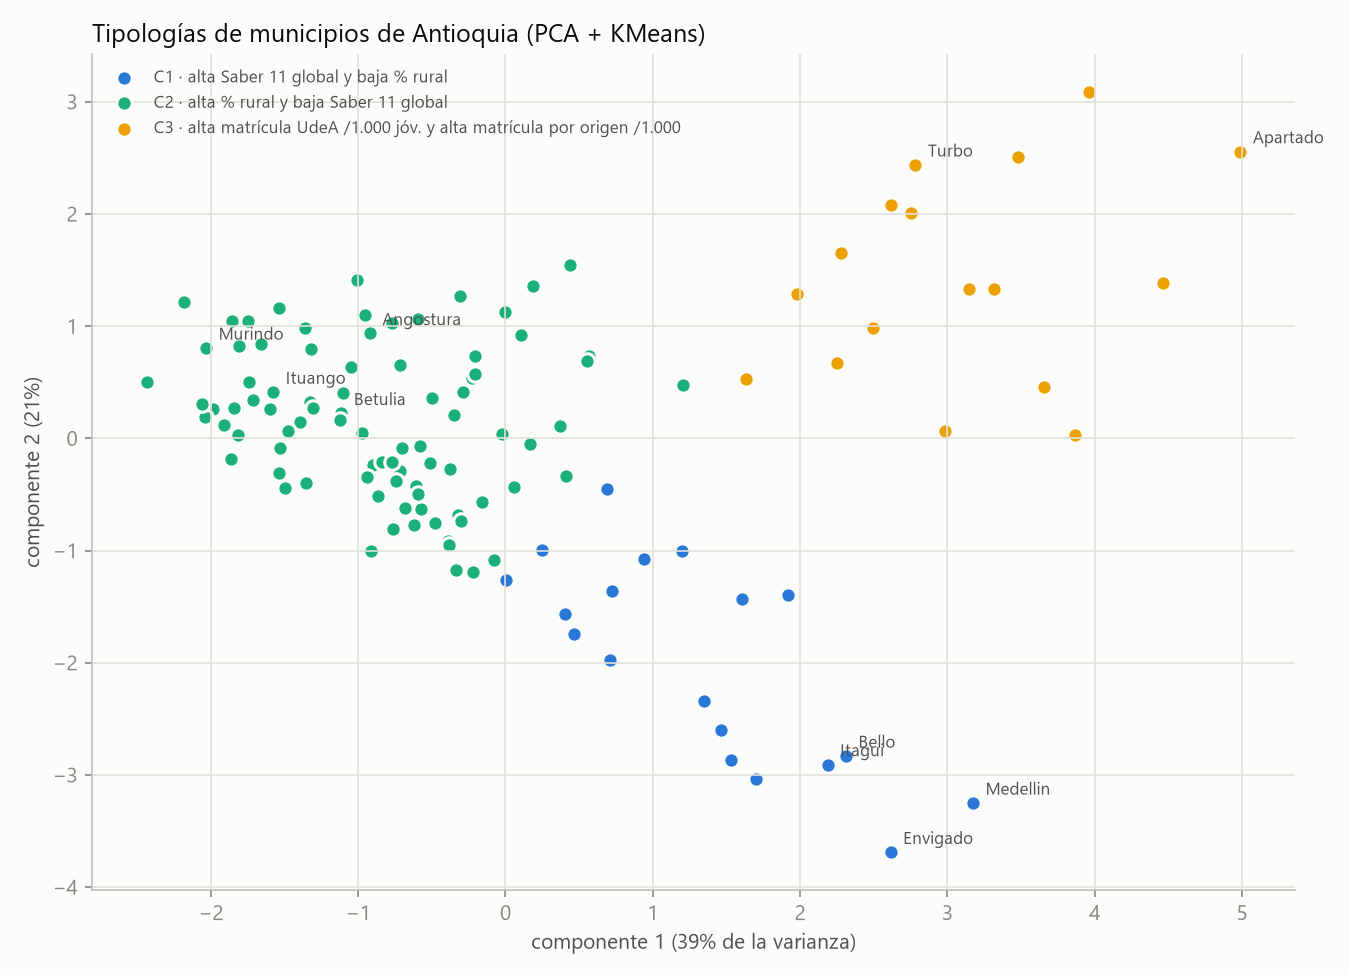

In [4]:
Image("../outputs/fig_pca_clusters.png")

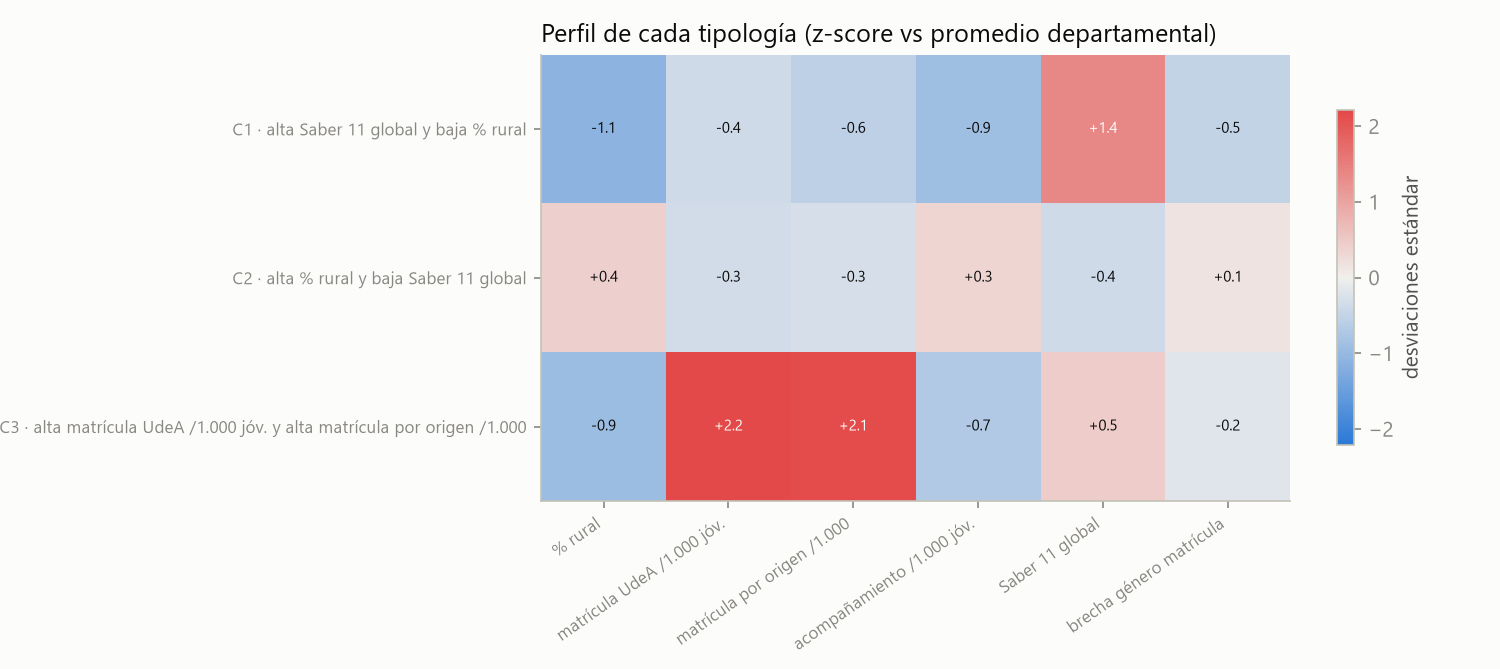

In [5]:
Image("../outputs/fig_perfil_clusters.png")

**Lectura.** Emergen tres tipologías: **C1** cabeceras urbanas del Valle de Aburrá y
Oriente con Saber 11 alto; **C2** (la mayoría) municipios rurales con Saber 11 bajo
y poca matrícula; **C3** municipios con sede regional UdeA (Turbo, Apartadó, Caucasia…)
donde la matrícula per cápita es alta — evidencia de que **la presencia de sede
regionaliza el acceso**.

## Ranking de municipios prioritarios

In [6]:
r = pd.read_csv("../outputs/ranking_brechas.csv")
r.head(15)

,COD_DANE,NOMBRE_MUNI,TIPOLOGIA,CLUSTER,INDICE_BRECHA,POB_15_19,PCT_RURAL,TASA_MATRIC_VIVE,TASA_BENEF,PROM_GLOBAL_SABER,BRECHA_GENERO_MATRIC
0,5093,BETULIA,C2 · alta % rural y baja Saber 11 global,1,86.1,1586,72.239518,1.425009,37.200504,210.025404,27.012825
1,5475,MURINDO,C2 · alta % rural y baja Saber 11 global,1,85.2,513,66.286084,1.116071,146.198830,187.222222,-47.544643
2,5361,ITUANGO,C2 · alta % rural y baja Saber 11 global,1,84.4,2168,72.044231,0.232234,105.166052,206.082863,59.335810
3,5038,ANGOSTURA,C2 · alta % rural y baja Saber 11 global,1,84.3,1098,77.438095,8.044243,52.823315,207.086806,2.740070
4,5125,CAICEDO,C2 · alta % rural y baja Saber 11 global,1,83.8,707,78.483899,0.000000,104.667610,215.840336,NaN
5,5842,URAMITA,C2 · alta % rural y baja Saber 11 global,1,81.3,637,69.615208,0.000000,78.492936,220.969697,NaN
6,5467,MONTEBELLO,C2 · alta % rural y baja Saber 11 global,1,81.1,490,71.960551,2.358491,42.857143,226.741935,53.537736
7,5044,ANZA,C2 · alta % rural y baja Saber 11 global,1,81.0,681,81.527865,2.506266,117.474302,223.279152,19.214703
8,5036,ANGELOPOLIS,C2 · alta % rural y baja Saber 11 global,1,80.6,465,60.692262,0.000000,92.473118,211.469231,NaN
9,5490,NECOCLI,C2 · alta % rural y baja Saber 11 global,1,80.3,4324,74.112441,15.954570,47.409806,205.014436,5.503891


**Insight accionable.** Los municipios del top del ranking (Betulia, Murindó,
Ituango, Angostura…) combinan alta ruralidad, bajo desempeño Saber 11, baja
matrícula universitaria **y** baja cobertura de los programas de acompañamiento:
son los candidatos naturales para expandir Semestre Cero / Soñares / PIES.

El mapa interactivo (`outputs/mapa_brechas.html`) permite explorar municipio a
municipio: tamaño = población joven, color = índice de brecha, tooltip con la
tipología y las tasas.